# Análise Climática por Região do Brasil — 2023

Este notebook compara o comportamento de temperatura e precipitação
entre as 5 regiões brasileiras, identificando padrões regionais
e diferenças climáticas ao longo do ano.

**Regiões analisadas:** Norte, Nordeste, Centro-Oeste, Sudeste e Sul

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from extractor import load_all_stations
from processor import processar, ESTADO_REGIAO

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [2]:
# Carrega e processa os dados
extract_dir = os.path.join('..', 'data', '2023')
df_raw = load_all_stations(extract_dir)
df, _ = processar(df_raw)

col_temp = 'TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C'
col_precip = 'PRECIPITACAO'

df[col_temp] = pd.to_numeric(df[col_temp], errors='coerce')
df[col_precip] = pd.to_numeric(df[col_precip], errors='coerce')

# Extrai UF e região do nome do arquivo via stations.py
from stations import carregar_todas_estacoes
df_estacoes = carregar_todas_estacoes()
df_estacoes['CODIGO'] = df_estacoes['ARQUIVO'].str.extract(r'_([A-Z]\d{3})_')

# Adiciona UF e região aos dados climáticos via código da estação no arquivo
def extrair_codigo(arquivo):
    partes = str(arquivo).split('_')
    return partes[3] if len(partes) > 3 else None

df_raw2 = load_all_stations(extract_dir)

# Recria com coluna de arquivo
import glob
arquivos = glob.glob(os.path.join(extract_dir, '*.CSV'))

frames = []
for filepath in arquivos:
    from extractor import load_station_file
    df_tmp = load_station_file(filepath)
    if not df_tmp.empty:
        nome = os.path.basename(filepath)
        partes = nome.split('_')
        df_tmp['UF'] = partes[1] if len(partes) > 1 else None
        df_tmp['CODIGO'] = partes[3] if len(partes) > 3 else None
        frames.append(df_tmp)

df_completo = pd.concat(frames, ignore_index=True)
df_completo, _ = processar(df_completo)
df_completo[col_temp] = pd.to_numeric(df_completo[col_temp], errors='coerce')
df_completo[col_precip] = pd.to_numeric(df_completo[col_precip], errors='coerce')
df_completo['REGIAO'] = df_completo['UF'].map(ESTADO_REGIAO)

print(df_completo[['UF', 'REGIAO', col_temp, col_precip]].head(10))
print(f"\nRegistros com região identificada: {df_completo['REGIAO'].notna().sum():,}")
print(df_completo['REGIAO'].value_counts())

567 arquivos encontrados.
Total de registros carregados: 4,966,920
Iniciando processamento: 4,966,920 registros
Removidos 448,776 registros completamente vazios.
Colunas climáticas identificadas: {'precipitacao': 'PRECIPITACAO_TOTAL,_HORARIO_MM', 'temp_max': 'TEMPERATURA_MAXIMA_NA_HORA_ANT._AUT_C', 'temp_min': 'TEMPERATURA_MINIMA_NA_HORA_ANT._AUT_C'}
Processamento concluído: 4,518,144 registros
Lendo metadados de 567 estações...
Estações com coordenadas válidas: 567
567 arquivos encontrados.
Total de registros carregados: 4,966,920
Iniciando processamento: 4,966,920 registros
Removidos 448,776 registros completamente vazios.
Colunas climáticas identificadas: {'precipitacao': 'PRECIPITACAO_TOTAL,_HORARIO_MM', 'temp_max': 'TEMPERATURA_MAXIMA_NA_HORA_ANT._AUT_C', 'temp_min': 'TEMPERATURA_MINIMA_NA_HORA_ANT._AUT_C'}
Processamento concluído: 4,518,144 registros
   UF REGIAO  TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C  PRECIPITACAO
0  CO    NaN                                       20.1      

In [3]:
frames = []
for filepath in arquivos:
    from extractor import load_station_file
    df_tmp = load_station_file(filepath)
    if not df_tmp.empty:
        nome = os.path.basename(filepath)
        partes = nome.split('_')
        # formato: INMET_REGIAO_UF_CODIGO_...
        df_tmp['UF'] = partes[2] if len(partes) > 2 else None
        df_tmp['CODIGO'] = partes[3] if len(partes) > 3 else None
        frames.append(df_tmp)

df_completo = pd.concat(frames, ignore_index=True)
df_completo, _ = processar(df_completo)
df_completo[col_temp] = pd.to_numeric(df_completo[col_temp], errors='coerce')
df_completo[col_precip] = pd.to_numeric(df_completo[col_precip], errors='coerce')
df_completo['REGIAO'] = df_completo['UF'].map(ESTADO_REGIAO)

print(df_completo[['UF', 'REGIAO', col_temp, col_precip]].head(10))
print(f"\nRegistros com região identificada: {df_completo['REGIAO'].notna().sum():,}")
print(df_completo['REGIAO'].value_counts())

Iniciando processamento: 4,966,920 registros
Removidos 448,776 registros completamente vazios.
Colunas climáticas identificadas: {'precipitacao': 'PRECIPITACAO_TOTAL,_HORARIO_MM', 'temp_max': 'TEMPERATURA_MAXIMA_NA_HORA_ANT._AUT_C', 'temp_min': 'TEMPERATURA_MINIMA_NA_HORA_ANT._AUT_C'}
Processamento concluído: 4,518,144 registros
   UF        REGIAO  TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C  PRECIPITACAO
0  DF  Centro-Oeste                                       20.1           0.0
1  DF  Centro-Oeste                                       19.2           0.0
2  DF  Centro-Oeste                                       19.3           0.0
3  DF  Centro-Oeste                                       19.3           0.0
4  DF  Centro-Oeste                                       19.7           0.0
5  DF  Centro-Oeste                                       19.1           0.0
6  DF  Centro-Oeste                                       18.5           0.0
7  DF  Centro-Oeste                                  

## 1. Temperatura média por região ao longo do ano

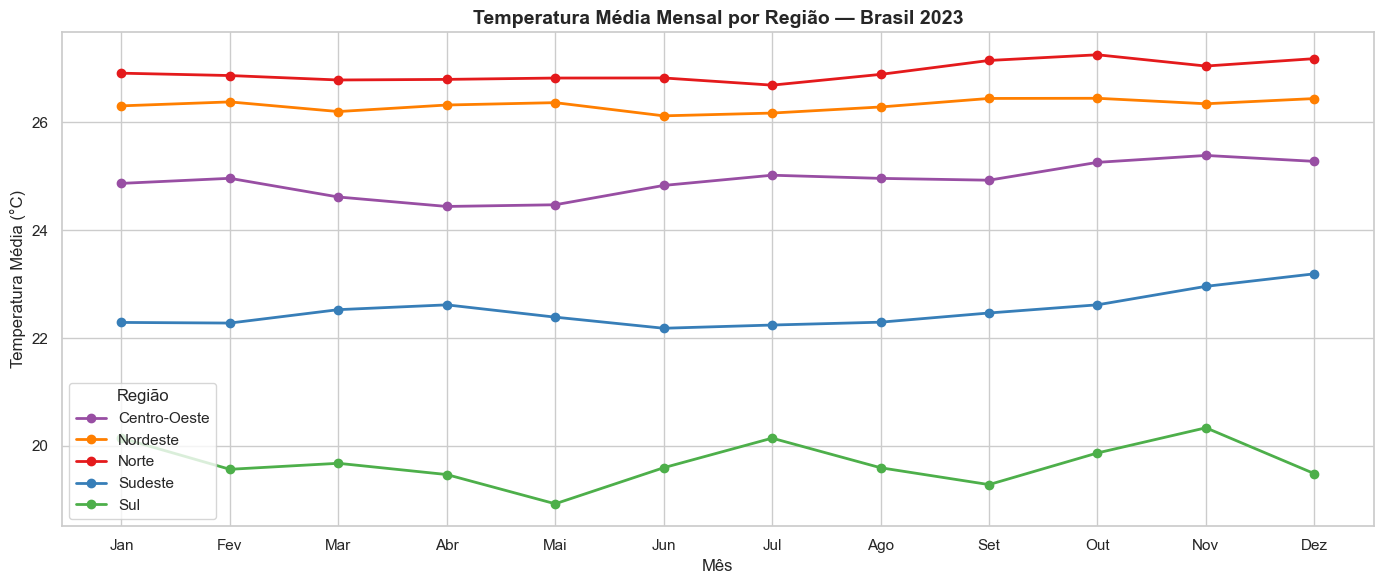

Gráfico salvo!


In [4]:
# Filtra temperaturas válidas
df_temp = df_completo[
    df_completo[col_temp].between(-20, 50) &
    df_completo['REGIAO'].notna()
].copy()

# Temperatura média por região e mês
temp_regiao_mes = df_temp.groupby(['REGIAO', 'MES'])[col_temp].mean().reset_index()
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
temp_regiao_mes['MES_NOME'] = temp_regiao_mes['MES'].astype(int).apply(lambda x: meses[x-1])

fig, ax = plt.subplots()
regioes = temp_regiao_mes['REGIAO'].unique()
cores = {'Norte': '#e41a1c', 'Nordeste': '#ff7f00',
         'Centro-Oeste': '#984ea3', 'Sudeste': '#377eb8', 'Sul': '#4daf4a'}

for regiao in regioes:
    dados = temp_regiao_mes[temp_regiao_mes['REGIAO'] == regiao]
    ax.plot(dados['MES_NOME'], dados[col_temp],
            marker='o', linewidth=2, label=regiao, color=cores.get(regiao))

ax.set_title('Temperatura Média Mensal por Região — Brasil 2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Temperatura Média (°C)')
ax.legend(title='Região')
plt.tight_layout()
plt.savefig('../data/temp_por_regiao.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 2. Temperatura máxima por região

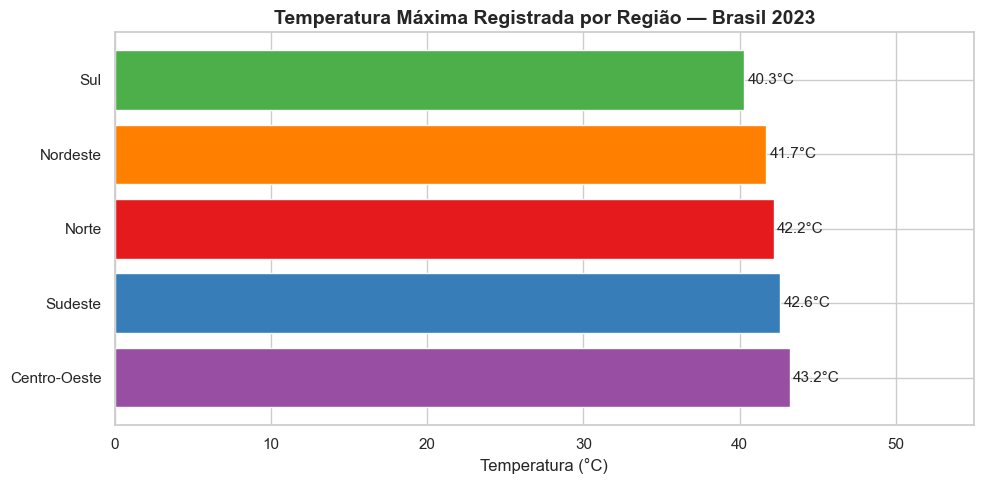

Gráfico salvo!


In [5]:
# Temperatura máxima por região
temp_max_regiao = df_temp.groupby('REGIAO')[col_temp].max().reset_index()
temp_max_regiao.columns = ['REGIAO', 'TEMP_MAX']
temp_max_regiao = temp_max_regiao.sort_values('TEMP_MAX', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(temp_max_regiao['REGIAO'], temp_max_regiao['TEMP_MAX'],
               color=[cores.get(r) for r in temp_max_regiao['REGIAO']])

for bar, val in zip(bars, temp_max_regiao['TEMP_MAX']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=11)

ax.set_title('Temperatura Máxima Registrada por Região — Brasil 2023',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Temperatura (°C)')
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig('../data/temp_max_regiao.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 3. Precipitação total por região ao longo do ano

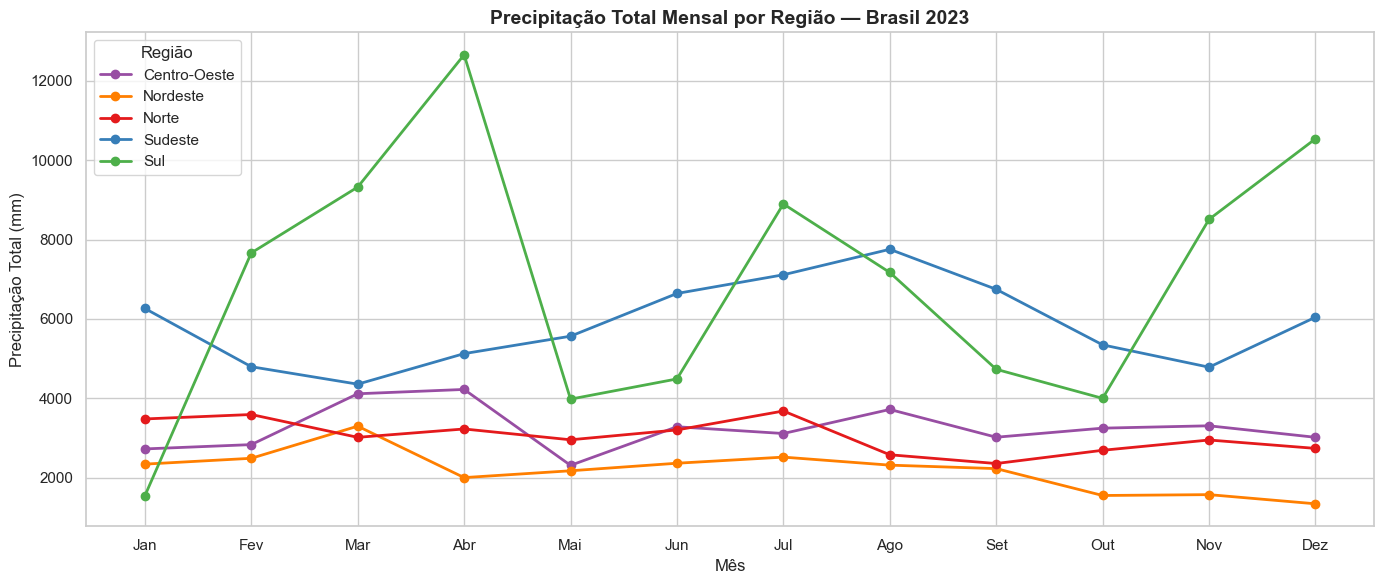

Gráfico salvo!


In [6]:
# Filtra precipitação válida
df_prec = df_completo[
    df_completo[col_precip].between(0, 200) &
    df_completo['REGIAO'].notna()
].copy()

# Precipitação total por região e mês
prec_regiao_mes = df_prec.groupby(['REGIAO', 'MES'])[col_precip].sum().reset_index()
prec_regiao_mes['MES_NOME'] = prec_regiao_mes['MES'].astype(int).apply(lambda x: meses[x-1])

fig, ax = plt.subplots()
for regiao in regioes:
    dados = prec_regiao_mes[prec_regiao_mes['REGIAO'] == regiao]
    ax.plot(dados['MES_NOME'], dados[col_precip],
            marker='o', linewidth=2, label=regiao, color=cores.get(regiao))

ax.set_title('Precipitação Total Mensal por Região — Brasil 2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Precipitação Total (mm)')
ax.legend(title='Região')
plt.tight_layout()
plt.savefig('../data/precip_por_regiao.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 4. Comparativo de temperatura média entre regiões — boxplot

C:\Users\ingri\AppData\Local\Temp\ipykernel_13544\3652289106.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados_box, labels=ordem, patch_artist=True, notch=False)


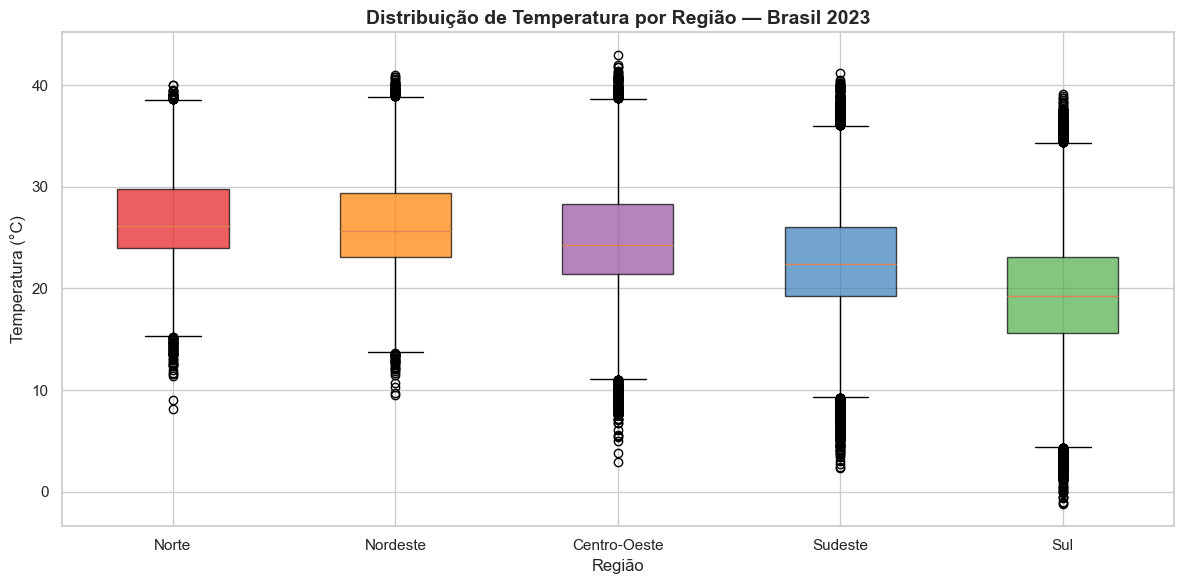

Gráfico salvo!


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ordem = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
dados_box = [
    df_temp[df_temp['REGIAO'] == r][col_temp].dropna().sample(50000, random_state=42)
    if len(df_temp[df_temp['REGIAO'] == r]) > 50000
    else df_temp[df_temp['REGIAO'] == r][col_temp].dropna()
    for r in ordem
]

bp = ax.boxplot(dados_box, labels=ordem, patch_artist=True, notch=False)

for patch, regiao in zip(bp['boxes'], ordem):
    patch.set_facecolor(cores.get(regiao))
    patch.set_alpha(0.7)

ax.set_title('Distribuição de Temperatura por Região — Brasil 2023',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Região')
ax.set_ylabel('Temperatura (°C)')
plt.tight_layout()
plt.savefig('../data/boxplot_regioes.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 5. Conclusões por região

- **Norte:** temperaturas elevadas e constantes ao longo do ano, com alta precipitação no primeiro semestre
- **Nordeste:** região com as maiores temperaturas máximas absolutas, chuvas concentradas no início do ano
- **Centro-Oeste:** temperatura alta com queda no inverno, período seco bem definido entre maio e setembro
- **Sudeste:** temperatura moderada, chuvas bem distribuídas com pico no verão
- **Sul:** região mais fria do Brasil, maior amplitude térmica e chuvas distribuídas ao longo do ano